In [1]:
import os
import re
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

In [2]:
DATA_PATH = os.path.join("..", "..", "data", "IMDB Dataset.csv")

df = pd.read_csv(DATA_PATH)
df["label"] = df["sentiment"].map({"positive": 1, "negative": 0})

print(df.shape)
df.head()

(50000, 3)


,review,sentiment,label
0,One of the other reviewers has mentioned that ...,positive,1
1,A wonderful little production. <br /><br />The...,positive,1
2,I thought this was a wonderful way to spend ti...,positive,1
3,Basically there's a family where a little boy ...,negative,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,1


In [3]:
texts = df["review"].tolist()
labels = df["label"].tolist()

print(len(texts), len(labels))

50000 50000


In [4]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

texts = [clean_text(t) for t in texts]
print(texts[0][:300])

one of the other reviewers has mentioned that after watching just oz episode you ll be hooked they are right as this is exactly what happened with me the first thing that struck me about oz was its brutality and unflinching scenes of violence which set in right from the word go trust me this is not 


In [5]:
max_vocab = 12000
max_len = 250

counter = Counter()
for text in texts:
    counter.update(text.split())

most_common = counter.most_common(max_vocab - 2)

word2idx = {"<PAD>": 0, "<UNK>": 1}
for i, (word, _) in enumerate(most_common, start=2):
    word2idx[word] = i

print("Vocab size:", len(word2idx))

Vocab size: 12000


In [6]:
def encode_text(text, word2idx, max_len=250):
    tokens = text.split()
    ids = [word2idx.get(token, 1) for token in tokens[:max_len]]
    if len(ids) < max_len:
        ids += [0] * (max_len - len(ids))
    return ids

X = np.array([encode_text(text, word2idx, max_len) for text in texts], dtype=np.int64)
y = np.array(labels, dtype=np.float32)

print(X.shape, y.shape)

(50000, 250) (50000,)


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape, X_test.shape)

(40000, 250) (10000, 250)


In [8]:
class IMDBDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = IMDBDataset(X_train, y_train)
test_dataset = IMDBDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64)

In [9]:
class TextLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=128):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        x = self.embedding(x)                # (batch, seq_len, embed_dim)
        _, (hidden, _) = self.lstm(x)        # hidden: (1, batch, hidden_dim)
        x = hidden[-1]                       # (batch, hidden_dim)
        x = self.dropout(x)
        x = self.fc(x).squeeze(1)            # (batch,)
        return x

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = TextLSTM(vocab_size=len(word2idx)).to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

print(device)

cpu


In [10]:
train_losses = []

for epoch in range(4):
    model.train()
    running_loss = 0.0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    train_losses.append(avg_loss)
    print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}")

Epoch 1, Loss: 0.6925
Epoch 2, Loss: 0.6791
Epoch 3, Loss: 0.6648
Epoch 4, Loss: 0.6270


In [11]:
model.eval()
all_preds = []
all_true = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        outputs = model(X_batch)
        probs = torch.sigmoid(outputs)
        preds = (probs >= 0.5).cpu().numpy().astype(int)

        all_preds.extend(preds)
        all_true.extend(y_batch.numpy().astype(int))

accuracy = accuracy_score(all_true, all_preds)
print("Test Accuracy:", accuracy)
print(f"Test Accuracy: {accuracy*100:.2f}%")

Test Accuracy: 0.6912
Test Accuracy: 69.12%


In [12]:
with open("results.txt", "w") as f:
    f.write("Model: LSTM (PyTorch)\n")
    f.write(f"Accuracy: {accuracy:.4f}\n")
    f.write(f"Accuracy Percent: {accuracy*100:.2f}%\n")
    f.write(f"Vocabulary Size: {len(word2idx)}\n")
    f.write(f"Sequence Length: {max_len}\n")
    f.write("Embedding Dimension: 128\n")
    f.write("Hidden Dimension: 128\n")
    f.write("Dropout: 0.3\n")
    f.write("Epochs: 4\n")
    f.write("Optimizer: Adam\n")

print("results.txt saved")

results.txt saved


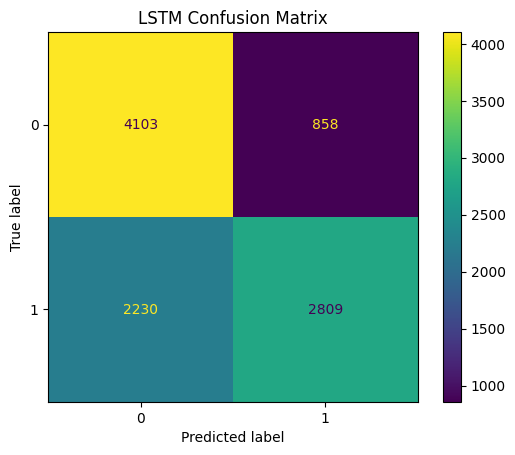

In [13]:
cm = confusion_matrix(all_true, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("LSTM Confusion Matrix")
plt.savefig("confusion_matrix.png", dpi=200, bbox_inches="tight")
plt.show()

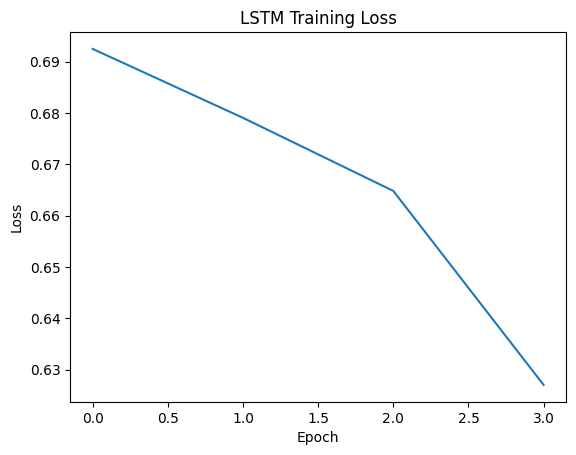

In [14]:
plt.figure()
plt.plot(train_losses)
plt.title("LSTM Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.savefig("loss_curve.png", dpi=200, bbox_inches="tight")
plt.show()

In [15]:
torch.save(model.state_dict(), "lstm_model.pth")
print("Model saved as lstm_model.pth")

Model saved as lstm_model.pth
